In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [5]:
# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/main_cumulative_bgs.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/main_cumulative_bgs.fits'))
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']
cat['EFFTIME_BGS'] = 0.1400 * cat['TSNR2_BGS']

1117800


In [6]:
# # Julien's bad fibers list
# # bad_fibers = np.array(Table.read('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/misc/badfibers.csv')['FIBER'])
# bad_fibers = np.array(Table.read('/Users/rongpu/Documents/Data/desi_data/everest/misc/badfibers.csv')['FIBER'])
# bad_fibers = np.append(bad_fibers, np.arange(2663, 2680+1))  # fibers affected by the CCD z5 defect
# bad_fibers = np.append(bad_fibers, [3402, 3429])  # "swapped" fibers
# bad_fibers = np.unique(bad_fibers)
# print(len(bad_fibers), 'bad fibers')
# # mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# # print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# # cat = cat[~mask_bad]

In [7]:
cat['MEAN_X'], cat['MEAN_Y'] = 0., 0.
for fiber in np.unique(cat['FIBER']):
    mask = cat['FIBER']==fiber
    cat['MEAN_X'][mask] = np.mean(cat['FIBERASSIGN_X'][mask])
    cat['MEAN_Y'][mask] = np.mean(cat['FIBERASSIGN_Y'][mask])

In [8]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 160.
mask = cat['EFFTIME_BGS']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # # ZDONE fibers
# # mask = cat['ZDONE']==1
# # print('ZDONE   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))

FIBERSTATUS    21436 1096364 0.019176954732510288
No data    0 1096364 0.0
Min depth    32511 1063853 0.029653472751750332


In [9]:
# # WISE and MEDIUM masks
# maskbits = [8, 9, 11]
# mask_clean = np.ones(len(cat), dtype=bool)
# for bit in maskbits:
#     mask_clean &= (cat['MASKBITS'] & 2**bit)==0
# print('MASKBITS', np.sum(mask_clean), np.sum(~mask_clean), np.sum(mask_clean)/len(mask_clean))
# cat = cat[mask_clean]

In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [11]:
mask_gal = cat['SPECTYPE']=='GALAXY'
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
mask_qso = cat['SPECTYPE']=='QSO'

# Force the very low-z objects to have SPECTYPE=STAR
cat['SPECTYPE'][mask_star] = 'STAR'

In [12]:
cat['Z'][mask_gal].max()

1.699744024426528

In [13]:
mask_quality = cat['ZWARN']==0
mask_quality &= cat['DELTACHI2']>100
mask_quality &= cat['Z']<1.5
print(np.sum(~mask_quality)/len(mask_quality))

# cat = cat[mask_quality]
# print(len(cat))

0.014235049391222283


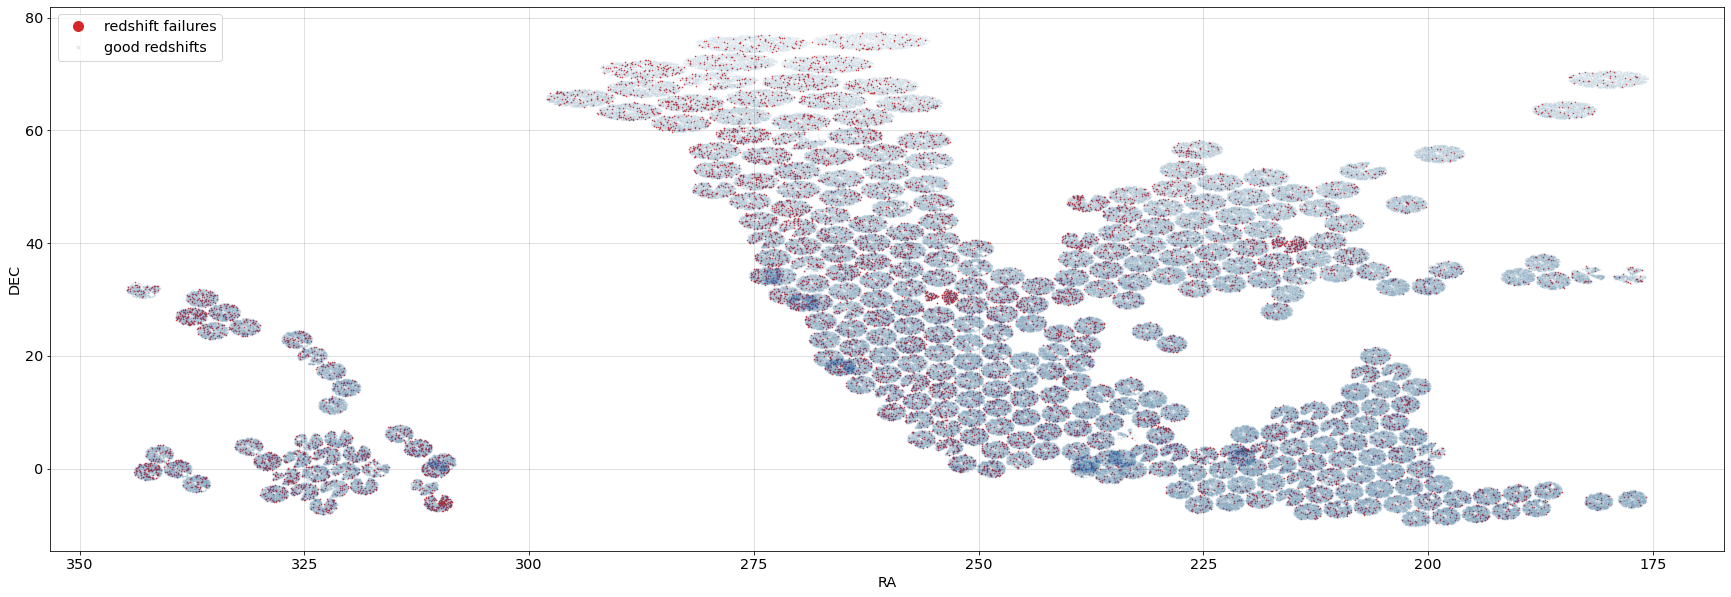

In [14]:
plt.figure(figsize=(30, 10))
plt.plot(cat['TARGET_RA'][~mask_quality], cat['TARGET_DEC'][~mask_quality], 'C3.', ms=1, label='redshift failures')
plt.plot(cat['TARGET_RA'][mask_quality], cat['TARGET_DEC'][mask_quality], 'C0.', ms=.3, alpha=0.1, label='good redshifts')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper left', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

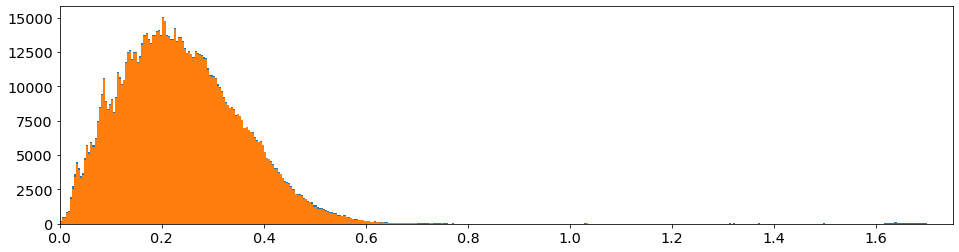

In [16]:
plt.figure(figsize=(16, 4))
plt.hist(cat['Z'][(~mask_star)], 500, log=False, range=(0, 2.))
plt.hist(cat['Z'][(~mask_star) & mask_quality], 500, log=False, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

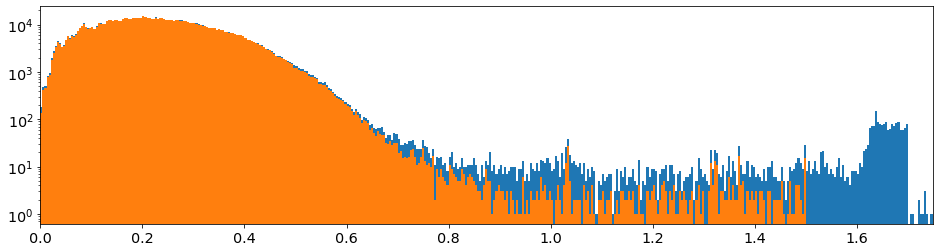

In [17]:
plt.figure(figsize=(16, 4))
plt.hist(cat['Z'][(~mask_star)], 500, log=True, range=(0, 2.))
plt.hist(cat['Z'][(~mask_star) & mask_quality], 500, log=True, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

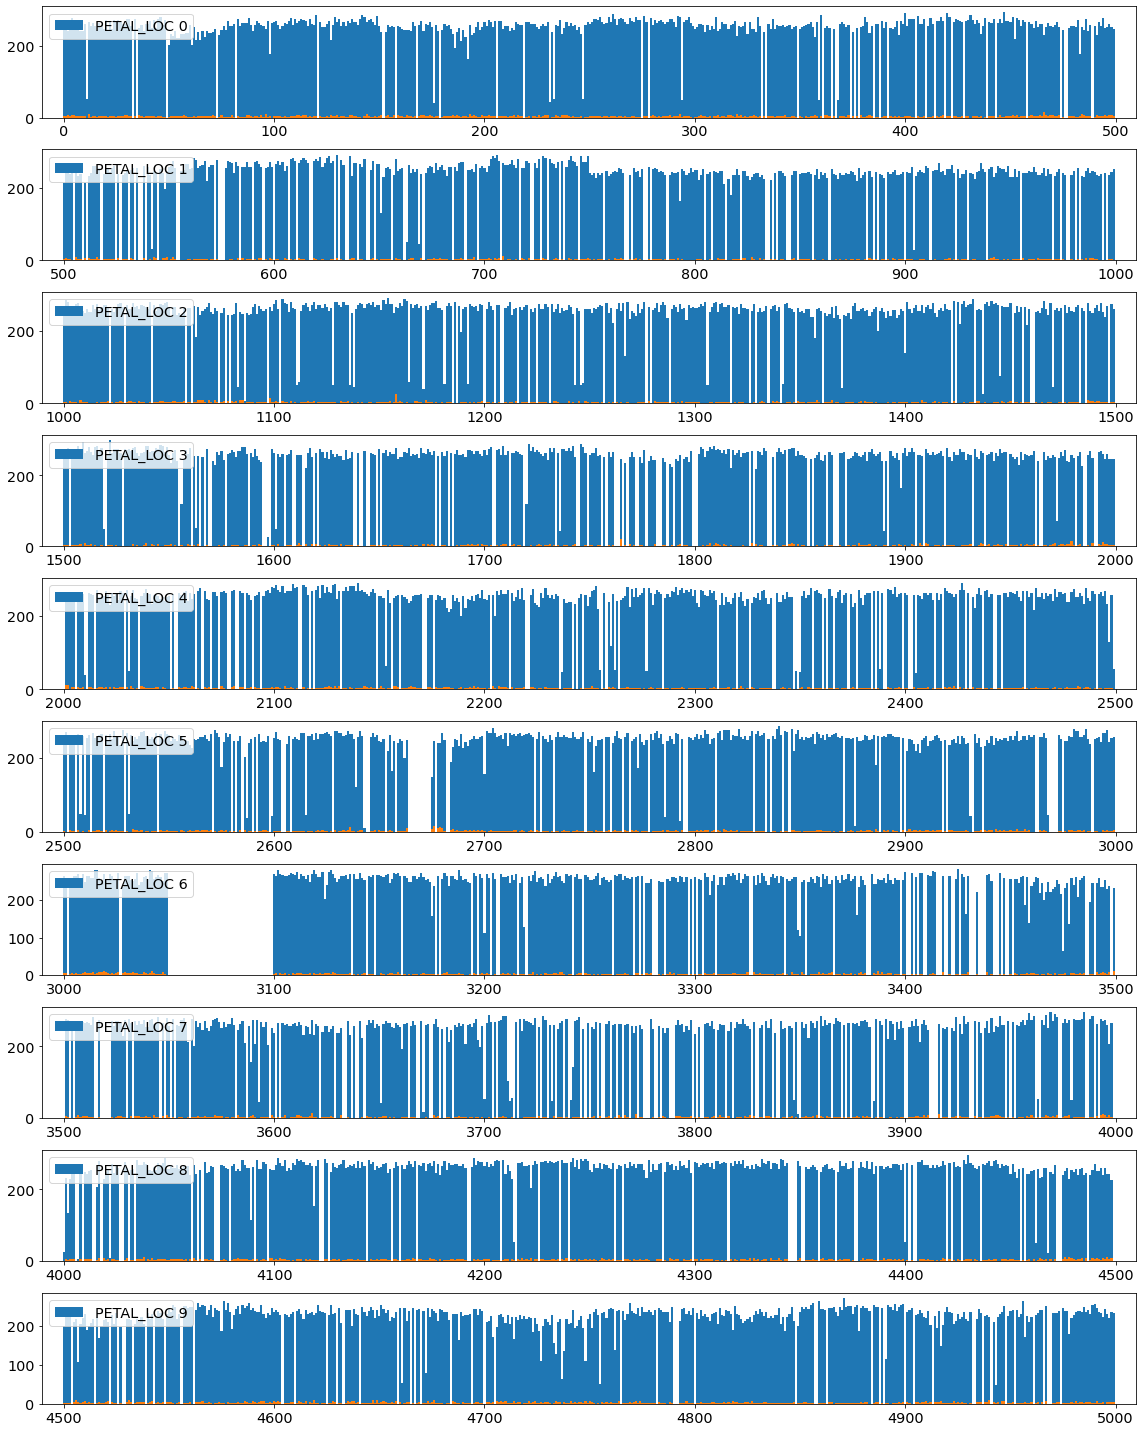

In [18]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (cat['FIBER']>fiber_min) & (cat['FIBER']<fiber_max)
    ax[index].hist(cat['FIBER'][mask], 500, range=(fiber_min, fiber_max), label='PETAL_LOC {}'.format(index))
    ax[index].hist(cat['FIBER'][mask & (~mask_quality)], 500, range=(fiber_min, fiber_max))
    ax[index].set_xlim(fiber_min-10, fiber_max+10)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

In [19]:
fiberstats = Table()
fiberstats['FIBER'], fiberstats['n_tot'] = np.unique(cat['FIBER'], return_counts=True)
fiberstats.sort('n_tot')

tt = Table()
tt['FIBER'], tt['n_fail'] = np.unique(cat['FIBER'][~mask_quality], return_counts=True)
fiberstats = join(fiberstats, tt, keys='FIBER', join_type='outer').filled(0)
fiberstats['frac_fail'] = fiberstats['n_fail']/fiberstats['n_tot']

error_floor = True

n, p = fiberstats['n_tot'].copy(), fiberstats['frac_fail'].copy()
if error_floor:
    p1 = np.maximum(p, 1/n)  # error floor
else:
    p1 = p
fiberstats['frac_fail_err'] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
fiberstats.sort('n_fail')

fiberstats

FIBER,n_tot,n_fail,frac_fail,frac_fail_err
int32,int64,int64,float64,float64
1445,75,0,0.0,0.013244146156223414
904,28,0,0.0,0.03507073235935592
3849,10,0,0.0,0.09486832980505137
2615,47,0,0.0,0.02104903202818048
222,261,0,0.0,0.0038240706999766436
4400,53,0,0.0,0.0186890776054207
1746,288,0,0.0,0.003466188816756638
231,44,0,0.0,0.022467523936912755
1752,264,0,0.0,0.00378069796855302


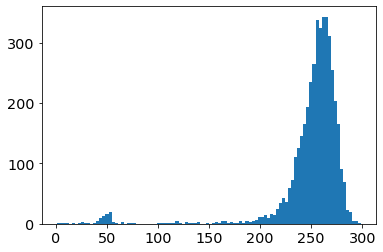

In [20]:
plt.hist(fiberstats['n_tot'], 100);

In [21]:
fiberstats['MEAN_X'], fiberstats['MEAN_Y'] = 0., 0.
for index, fiber in enumerate(fiberstats['FIBER']):
    mask = cat['FIBER']==fiber
    fiberstats['MEAN_X'][index], fiberstats['MEAN_Y'][index] = cat['MEAN_X'][mask][0], cat['MEAN_Y'][mask][0]

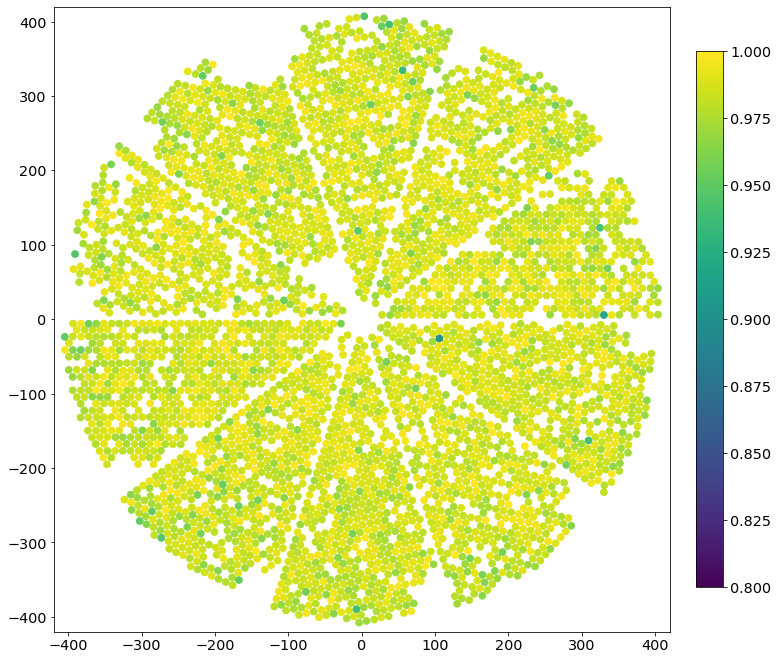

In [23]:
mask = fiberstats['n_tot']>100

plt.figure(figsize=(12, 11.5))
plt.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=1-fiberstats['frac_fail'][mask],
            s=45, vmin=0.8, vmax=1., cmap='viridis')
plt.axis([-420, 420, -420, 420])
plt.colorbar(fraction=0.04, pad=0.04)
# plt.axis('off')
plt.show()

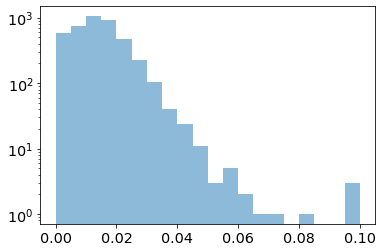

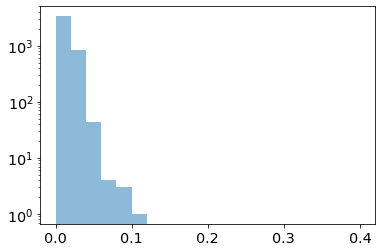

In [25]:
# mask_good = (fiberstats['n_tot']>30) & (~np.in1d(fiberstats['FIBER'], bad_fibers))
# mask_bad = (fiberstats['n_tot']>30) & np.in1d(fiberstats['FIBER'], bad_fibers)

# plt.hist(fiberstats['frac_fail'][mask_good], 20, range=(0, 0.4), log=True, alpha=0.5)
# plt.hist(fiberstats['frac_fail'][mask_bad], 20, range=(0, 0.4), log=True, alpha=0.5)
# plt.show()

plt.hist(fiberstats['frac_fail'], 20, log=True, alpha=0.5)
plt.show()

plt.hist(fiberstats['frac_fail'], 20, range=(0, 0.4), log=True, alpha=0.5)
plt.show()

__Flag the worst fibers__

In [46]:
# frac_fail_threshold = np.percentile(fiberstats['frac_fail'], 99.5)
frac_fail_threshold = 0.05

print(frac_fail_threshold)
mask_threshold = fiberstats['frac_fail']>=frac_fail_threshold
# mask_threshold &= fiberstats['n_tot']>100
print(np.sum(mask_threshold), np.sum(mask_threshold)/len(mask_threshold))
print(np.mean(fiberstats['frac_fail'][mask_threshold]), np.mean(fiberstats['frac_fail']), np.mean(fiberstats['frac_fail'][~mask_threshold]))
print(np.sum(fiberstats['n_fail'][mask_threshold])/np.sum(fiberstats['n_fail']))

bad_fibers = fiberstats['FIBER'][mask_threshold].copy()
print(len(bad_fibers))
print(list(sorted(bad_fibers)))

0.05
16 0.0037647058823529413
0.06849886539838518 0.014382300960717938 0.014177798119196285
0.011093502377179081
16
[466, 1098, 1128, 1158, 1765, 1890, 1979, 2643, 2675, 2676, 2679, 3618, 3651, 3713, 4214, 4748]


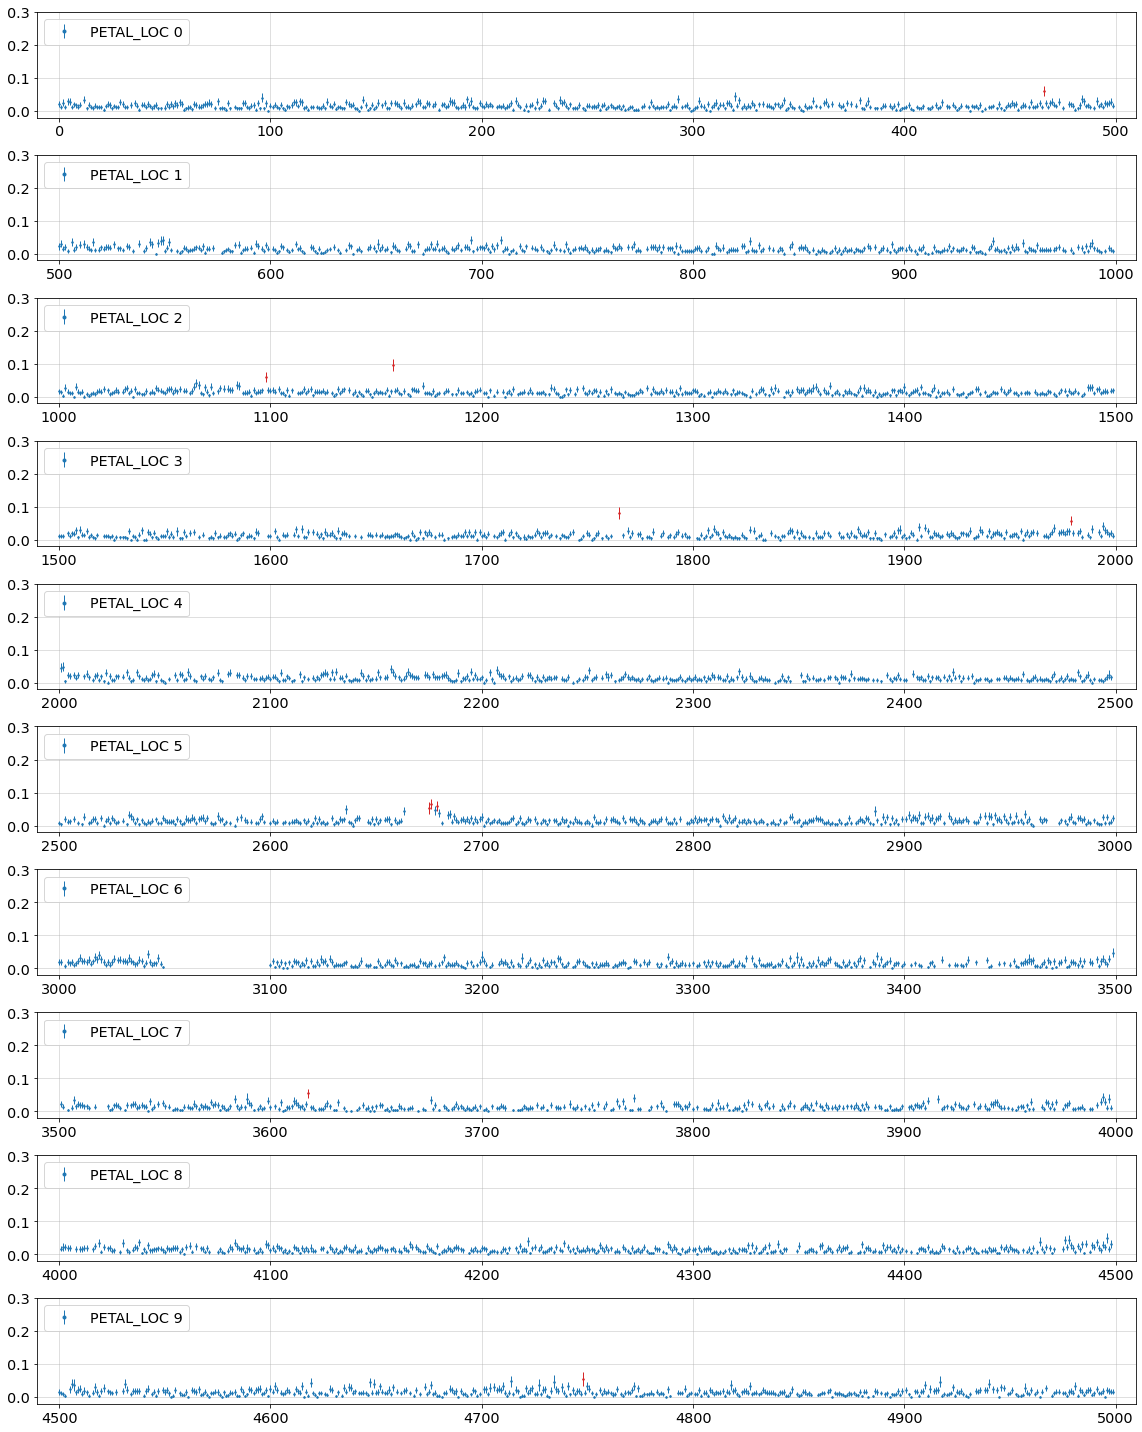

In [40]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (fiberstats['FIBER']>fiber_min) & (fiberstats['FIBER']<fiber_max)
    mask &= (fiberstats['n_tot']>100)
    mask_good = mask & (~np.in1d(fiberstats['FIBER'], bad_fibers))
    mask_bad = mask & np.in1d(fiberstats['FIBER'], bad_fibers)
    # plt.figure(figsize=(16, 2))
    ax[index].errorbar(fiberstats['FIBER'][mask_good], fiberstats['frac_fail'][mask_good], 
                       yerr=(np.clip(fiberstats['frac_fail_err'][mask_good], None, fiberstats['frac_fail'][mask_good]), fiberstats['frac_fail_err'][mask_good]),
                       color='C0', fmt='.', ms=3, elinewidth=1, label='PETAL_LOC {}'.format(index))
    ax[index].errorbar(fiberstats['FIBER'][mask_bad], fiberstats['frac_fail'][mask_bad],
                   yerr=(np.clip(fiberstats['frac_fail_err'][mask_bad], None, fiberstats['frac_fail'][mask_bad]), fiberstats['frac_fail_err'][mask_bad]),
                   color='C3', fmt='.', ms=3, elinewidth=1)
    ax[index].grid(alpha=0.5)
    ax[index].set_yticks([0., 0.1, 0.2, 0.3], minor=False)
    ax[index].set_ylim(-0.02, 0.3)
    ax[index].set_xlim(fiber_min-10, fiber_max+10)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

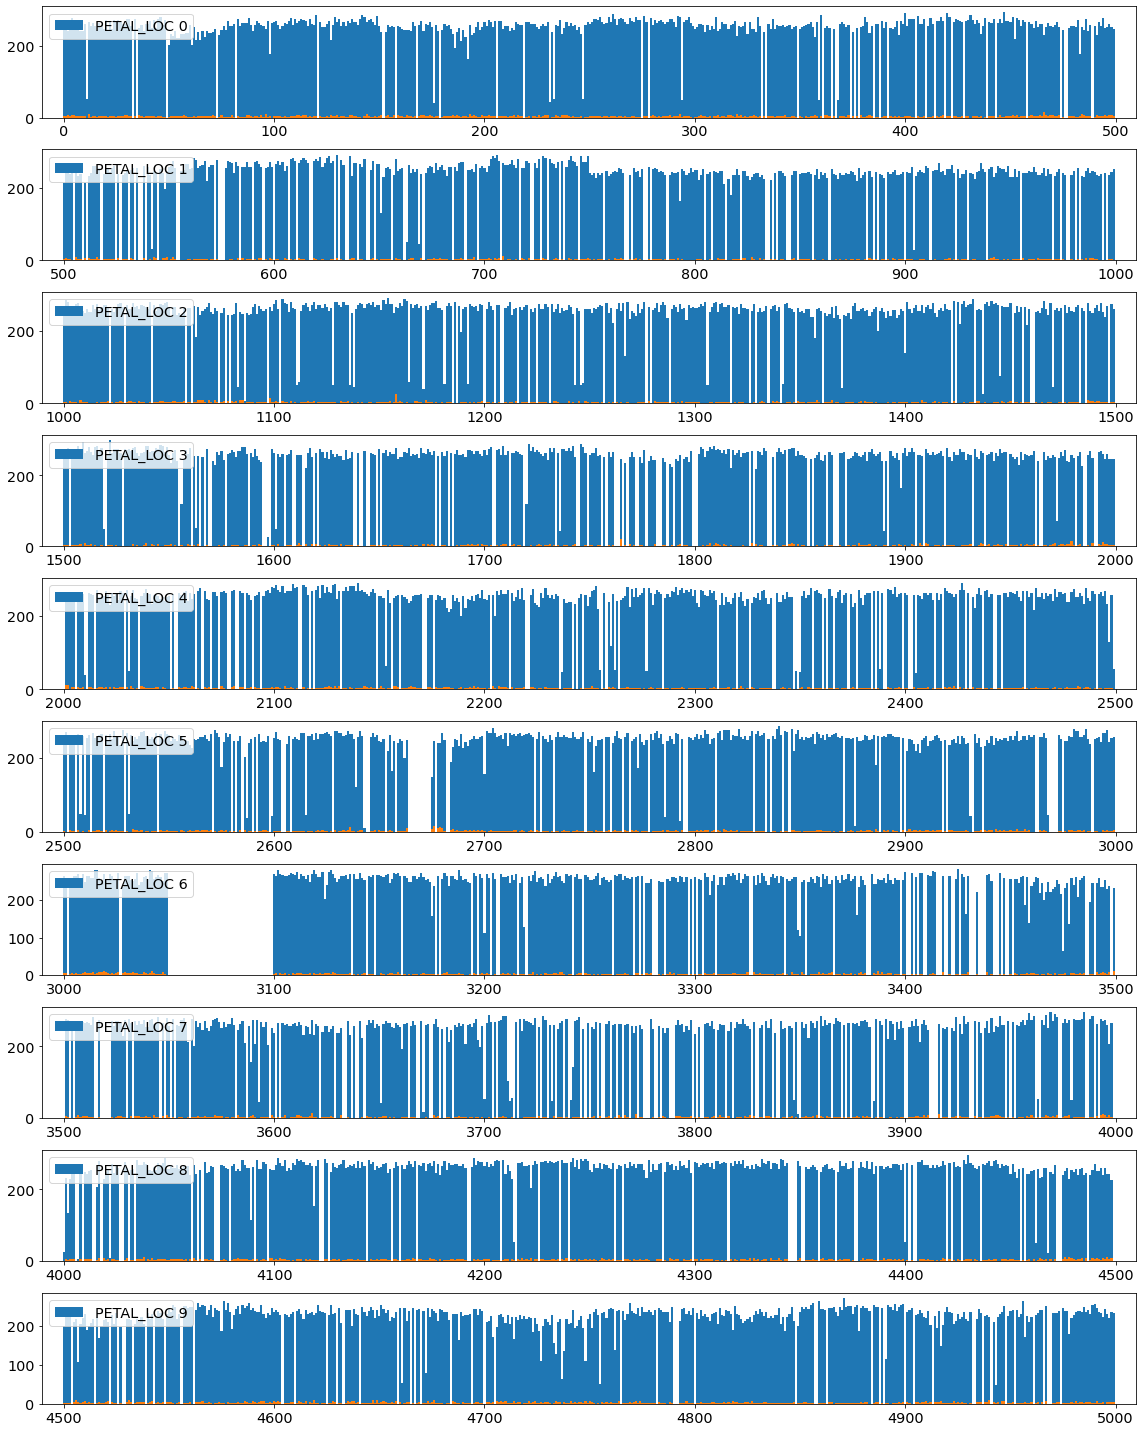

In [41]:
fig, ax = plt.subplots(10, 1, figsize=(16, 20))
for index in range(10):
    fiber_min, fiber_max = index*500-0.5, (index+1)*500-0.5
    mask = (cat['FIBER']>fiber_min) & (cat['FIBER']<fiber_max)
    # mask &= (~np.in1d(cat['FIBER'], bad_fibers))
    ax[index].hist(cat['FIBER'][mask], 500, range=(fiber_min, fiber_max), label='PETAL_LOC {}'.format(index))
    ax[index].hist(cat['FIBER'][mask & (~mask_quality)], 500, range=(fiber_min, fiber_max))
    ax[index].set_xlim(fiber_min-10, fiber_max+10)
    ax[index].legend(loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

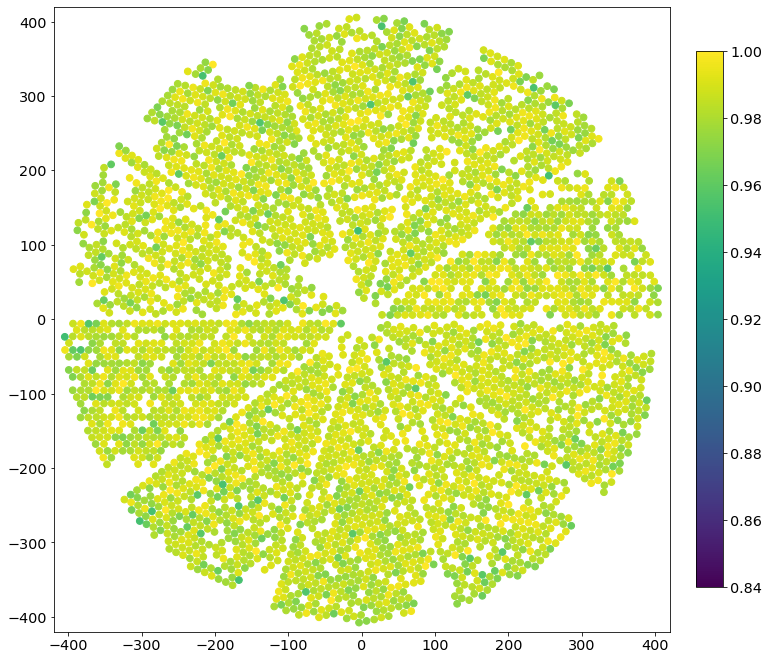

In [42]:
mask = fiberstats['n_tot']>100
mask &= (~np.in1d(fiberstats['FIBER'], bad_fibers))

plt.figure(figsize=(12, 11.5))
plt.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=1-fiberstats['frac_fail'][mask],
            s=45, vmin=0.84, vmax=1., cmap='viridis')
plt.axis([-420, 420, -420, 420])
plt.colorbar(fraction=0.04, pad=0.04)
# plt.axis('off')
plt.show()

In [ ]:
# np.savetxt('/Users/rongpu/Documents/Data/desi_data/everest/misc/bad_fibers_20211117.txt', bad_fibers2, fmt='%s')